# MP Surfaces benchmark with IP-Orch

This notebook shows how to use `ip-orch` for a benchmark while keeping the logic readable.

The original workflow is split across three parts:

1. Prepare Materials Project surface data in the default environment,
2. Run MLIP inference,
3. Plot and summarize results.

## What IP-Orch provides

`ip-orch` is a small orchestration layer for MLIP benchmarking. Its central idea is simple:

1. You write one ASE-style Python function,
2. IP-Orch creates the requested MLIP calculator in the right Conda environment,
3. IP-Orch calls your function as `main(calculator_name, ase_calculator)` or through a notebook function wrapper.

This lets one benchmark run across models that normally live in incompatible software environments.

## Repository features used here

The notebook uses these repository features:

- `IPOrch().supported_models()` lists model aliases known by the package.
- `IPOrch().add_model(env, model)` registers an environment/model pair.
- `IPOrch().run(function, models=[...])` runs a Python function across selected models.
- `parallel=N` can run several selected models concurrently.
- The worker injects an ASE calculator, so benchmark code stays model-agnostic.

Other package features are summarized near the end of the notebook.

## Surface energy formula

For each slab, the MLIP surface energy is computed as:

`gamma = (E_slab - N_atoms * E_bulk_per_atom) / (2 * area)`

The factor `2` appears because the slab has two exposed surfaces.

## Inspect configured models

This cell creates the Python API object and prints the known model aliases. A configured alias can be selected later with `models=[...]`.

In [1]:
from ip_orch import IPOrch

orch = IPOrch()

orch.supported_models()

 alias             registry         repo                                                       configured  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  allegro-mp-l      allegro_mp_l     https://github.com/mir-group/nequip                        ×           
  chgnet            chgnet           https://github.com/CederGroupHub/chgnet                    ×           
  dpa-3.1-3m-ft     dpa_3_1_3m_ft    https://github.com/deepmodeling/deepmd-kit                 ×           
  dpa-3.1-mptrj     dpa_3_1_mptrj    https://github.com/deepmodeling/deepmd-kit                 ×           
  eqnorm-mptrj      eqnorm_mptrj     https://github.com/yzchen08/eqnorm                         ×           
  grace-1l-oam      grace_1l_oam     https://github.com/ICAMS/grace-tensorpotential             ×           
  grace-2l-mp-r6    grace_2l_mp      https://github.com/ICAMS/grace-tensorpotential             ×           
  grace-2l-oam      grace_2l_oam     https://github.com/ICAMS/grace-tensorpotential             ×           
  hienet            hienet           https://github.com/divelab/AIRS/tree/main/OpenMat/HIENet   ×           
  m3gnet            m3gnet           https://github.com/materialyzeai/m3gnet                    ×           
  mace-mp           mace_mp          https://github.com/ACEsuit/mace                            ×           
  mace-mp-0         mace_mp_0        https://github.com/ACEsuit/mace                            ×           
  mace-mpa-0        mace_mpa_0       https://github.com/ACEsuit/mace                            ×           
  matris-10m-mp     matris_10m_mp    https://github.com/HPC-AI-Team/MatRIS                      ×           
  matris-10m-oam    matris_10m_oam   https://github.com/HPC-AI-Team/MatRIS                      ×           
  mattersim-v1      mattersim_v1     https://github.com/microsoft/mattersim                     ×           
  nequip-mp-l       nequip_mp_l      https://github.com/mir-group/nequip                        ×           
  nequip-oam-l      nequip_oam_l     https://github.com/mir-group/nequip                        ×           
  nequip-oam-xl     nequip_oam_xl    https://github.com/mir-group/nequip                        ×           
  nequix-mp         nequix_mp        https://github.com/atomicarchitects/nequix                 ×           
  nequix-mp-1-pft   nequix_mp_pft    https://github.com/atomicarchitects/nequix                 ×           
  nequix-mp-pft     nequix_mp_pft    https://github.com/atomicarchitects/nequix                 ×           
  orb-v2            orb_v2           https://github.com/orbital-materials/orb-models            ×           
  orb-v2-mptrj      orb_v2_mptrj     https://github.com/orbital-materials/orb-models            ×           
  orb-v3            orb_v3           https://github.com/orbital-materials/orb-models            ×           
  pet-oam-xl        pet_oam_xl       https://github.com/lab-cosmo/upet                          ×           
  sevennet-l3i5     sevennet_l3i5    https://github.com/MDIL-SNU/SevenNet                       ×           
  sevennet-omni     sevennet_omni    https://github.com/MDIL-SNU/SevenNet                       ×           
  tace-v1-oam-m     tace_v1_oam_m    https://github.com/xvzemin/tace                            ×         

## Select models and environment variables

This cell chooses which MLIP aliases to run and sets benchmark-specific environment variables.

`IPORCH_MP_ROOT` points to the local Materials Project cache. Keep this path visible to every MLIP environment, because IP-Orch workers will read these files.

In [ ]:
import os
from pathlib import Path

from dotenv import load_dotenv

PARALLEL = 1

# Choose the MLIP aliases. The pair means: use the Conda env named "mace"
# when the selected model alias is "mace-mp".
orch.add_model("mace", "mace-mp")
orch.add_model("mace", "mace-mpa-0")
orch.add_model("orb", "orb-v2")
orch.add_model("orb", "orb-v2-mptrj")
orch.add_model("orb", "orb-v3")
orch.add_model("m3gnet", "m3gnet")
orch.add_model("chgnet", "chgnet")

MODELS = ["mace-mp", "mace-mpa-0", "orb-v2-mptrj", "orb-v2", "orb-v3", "chgnet", "m3gnet"]

# Notebook/base-environment setup.
load_dotenv(".env")
os.environ["API_MP"] = os.getenv("API_MP")

# Small first run. Remove or increase this when you want the full benchmark.
os.environ["IPORCH_SURFACES_MAX_MATERIALS"] = "20"

# Use an absolute cache path so the notebook and every IP-Orch worker read the same files.
os.environ["IPORCH_MP_ROOT"] = str(Path("cache").resolve())

# Keep this as "1" while rebuilding old cache files. After a successful run, set to "0".
os.environ["IPORCH_REBUILD_MP_CACHE"] = "1"

print("MP cache:", os.environ["IPORCH_MP_ROOT"])
orch.supported_models()

Added: env='mace' model='mace-mp'

Added: env='mace' model='mace-mpa-0'

Added: env='orb' model='orb-v2'

Added: env='orb' model='orb-v2-mptrj'

Added: env='orb' model='orb-v3'

Added: env='m3gnet' model='m3gnet'

Added: env='chgnet' model='chgnet'

MP cache: /home/pedro.zanineli/Projects/package/surfaces/cache


 alias             registry         repo                                                       configured  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  chgnet            chgnet           https://github.com/CederGroupHub/chgnet                    ✓           
  m3gnet            m3gnet           https://github.com/materialyzeai/m3gnet                    ✓           
  mace-mp           mace_mp          https://github.com/ACEsuit/mace                            ✓           
  mace-mpa-0        mace_mpa_0       https://github.com/ACEsuit/mace                            ✓           
  orb-v2            orb_v2           https://github.com/orbital-materials/orb-models            ✓           
  orb-v2-mptrj      orb_v2_mptrj     https://github.com/orbital-materials/orb-models            ✓           
  orb-v3            orb_v3           https://github.com/orbital-materials/orb-models            ✓           
  allegro-mp-l      allegro_mp_l     https://github.com/mir-group/nequip                        ×           
  dpa-3.1-3m-ft     dpa_3_1_3m_ft    https://github.com/deepmodeling/deepmd-kit                 ×           
  dpa-3.1-mptrj     dpa_3_1_mptrj    https://github.com/deepmodeling/deepmd-kit                 ×           
  eqnorm-mptrj      eqnorm_mptrj     https://github.com/yzchen08/eqnorm                         ×           
  grace-1l-oam      grace_1l_oam     https://github.com/ICAMS/grace-tensorpotential             ×           
  grace-2l-mp-r6    grace_2l_mp      https://github.com/ICAMS/grace-tensorpotential             ×           
  grace-2l-oam      grace_2l_oam     https://github.com/ICAMS/grace-tensorpotential             ×           
  hienet            hienet           https://github.com/divelab/AIRS/tree/main/OpenMat/HIENet   ×           
  mace-mp-0         mace_mp_0        https://github.com/ACEsuit/mace                            ×           
  matris-10m-mp     matris_10m_mp    https://github.com/HPC-AI-Team/MatRIS                      ×           
  matris-10m-oam    matris_10m_oam   https://github.com/HPC-AI-Team/MatRIS                      ×           
  mattersim-v1      mattersim_v1     https://github.com/microsoft/mattersim                     ×           
  nequip-mp-l       nequip_mp_l      https://github.com/mir-group/nequip                        ×           
  nequip-oam-l      nequip_oam_l     https://github.com/mir-group/nequip                        ×           
  nequip-oam-xl     nequip_oam_xl    https://github.com/mir-group/nequip                        ×           
  nequix-mp         nequix_mp        https://github.com/atomicarchitects/nequix                 ×           
  nequix-mp-1-pft   nequix_mp_pft    https://github.com/atomicarchitects/nequix                 ×           
  nequix-mp-pft     nequix_mp_pft    https://github.com/atomicarchitects/nequix                 ×           
  pet-oam-xl        pet_oam_xl       https://github.com/lab-cosmo/upet                          ×           
  sevennet-l3i5     sevennet_l3i5    https://github.com/MDIL-SNU/SevenNet                       ×           
  sevennet-omni     sevennet_omni    https://github.com/MDIL-SNU/SevenNet                       ×           
  tace-v1-oam-m     tace_v1_oam_m    https://github.com/xvzemin/tace                            ×         

## Download Materials Project data in the notebook environment

Run this cell in the default `iporch` environment. It talks to the Materials Project REST API with `requests` and uses `pymatgen` only while building the local cache.

Important energy detail: the bulk reference used below comes from `/materials/thermo/` as `energy_per_atom`. The `/materials/summary/` endpoint also exposes an `energy_per_atom`, but for this benchmark it is not in the same reference as the MLIPs and gives very large bulk errors. The summary endpoint is still used to retrieve the bulk structure.

The cache stores plain ASE `Atoms`, numpy arrays, and simple Python data. This matters because the MLIP environments used by IP-Orch should not need `mp_api` or `pymatgen` installed.


In [3]:
import os
import pickle
import warnings
from pathlib import Path

import numpy as np
import requests
from ase import Atoms
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from pymatgen.io.cif import CifParser

warnings.filterwarnings("ignore")

mp_root = Path(os.environ["IPORCH_MP_ROOT"])
surfaces_dir = mp_root / "surfaces"
dft_dir = mp_root / "dft"
marker_path = mp_root / ".cache"
surfaces_dir.mkdir(parents=True, exist_ok=True)
dft_dir.mkdir(parents=True, exist_ok=True)

api_key = os.getenv("API_MP") or os.getenv("MP_API_KEY")
if not api_key:
    raise RuntimeError("Set API_MP or MP_API_KEY before downloading Materials Project data")

max_materials = os.getenv("IPORCH_SURFACES_MAX_MATERIALS")
max_materials = int(max_materials) if max_materials else None
force_rebuild = os.getenv("IPORCH_REBUILD_MP_CACHE", "0") == "1"

headers = {"X-API-KEY": api_key}
base_url = "https://api.materialsproject.org"


def mp_get(path, params):
    response = requests.get(f"{base_url}{path}", headers=headers, params=params, timeout=120)
    response.raise_for_status()
    return response.json()["data"]


def plain_ase_atoms(atoms):
    """Drop pymatgen's MSONAtoms subclass so MLIP envs only need ASE to unpickle."""
    return Atoms(
        symbols=atoms.get_chemical_symbols(),
        positions=atoms.get_positions(),
        cell=atoms.cell.array,
        pbc=atoms.pbc,
    )


has_portable_cache = (
    marker_path.exists()
    and any(surfaces_dir.glob("mp_surfaces_data_*.pkl"))
    and any(dft_dir.glob("mp_surfaces_energy_dft_*.npy"))
)

if has_portable_cache and not force_rebuild:
    print(f"Using portable MP cache in {mp_root}")
else:
    limit = max_materials or 1000
    print(f"Building portable MP cache in {mp_root}")
    surface_docs = mp_get(
        "/materials/surface_properties/",
        {"_fields": "material_id,surfaces", "_limit": limit},
    )

    for doc in surface_docs:
        material_id = str(doc["material_id"])
        dft_path = dft_dir / f"mp_surfaces_energy_dft_{material_id}.npy"
        surface_path = surfaces_dir / f"mp_surfaces_data_{material_id}.pkl"

        summary = mp_get(
            "/materials/summary/",
            {
                "material_ids": material_id,
                "_fields": "material_id,structure",
                "_limit": 1,
            },
        )[0]
        thermo = mp_get(
            "/materials/thermo/",
            {
                "material_ids": material_id,
                "_fields": "material_id,energy_per_atom",
                "_limit": 1,
            },
        )
        if not thermo:
            raise RuntimeError(f"No thermo energy_per_atom found for {material_id}")
        dft_bulk_per_atom = float(thermo[0]["energy_per_atom"])
        bulk = plain_ase_atoms(AseAtomsAdaptor.get_atoms(Structure.from_dict(summary["structure"])))

        # The benchmark needs the MP-compatible bulk energy per atom. The first entry is kept
        # for compatibility with the old npy format: [total_energy, energy_per_atom].
        np.save(dft_path, [np.nan, dft_bulk_per_atom])

        slabs = []
        surface_energies = []
        miller_indices = []
        for surface in doc.get("surfaces") or []:
            structure = CifParser.from_str(surface["structure"]).parse_structures()[0]
            slabs.append(plain_ase_atoms(AseAtomsAdaptor.get_atoms(structure)))
            surface_energies.append(surface["surface_energy_EV_PER_ANG2"])
            miller_indices.append(surface["miller_index"])

        payload = {
            "cache_format": "iporch_surface_cache_v3",
            "material_id": material_id,
            "mp_surfaces_structure": slabs,
            "mp_surfaces_nsites": np.array([len(slab) for slab in slabs]),
            "mp_surfaces_areas": np.array([np.linalg.norm(np.cross(slab.cell[0], slab.cell[1])) for slab in slabs]),
            "mp_surface_energy_EV_PER_ANG2": np.array(surface_energies),
            "mp_surfaces_miller_index": miller_indices,
            "mp_bulk_structure": bulk,
            "mp_bulk_energy_per_atom_source": "materials/thermo.energy_per_atom",
        }
        with surface_path.open("wb") as handle:
            pickle.dump(payload, handle)

    marker_path.write_text("portable cache built by surfaces_benchmark.ipynb\n")

print(f"Cache root: {mp_root}")
print(f"Surface files: {len(list(surfaces_dir.glob('mp_surfaces_data_*.pkl')))}")
print(f"DFT files: {len(list(dft_dir.glob('mp_surfaces_energy_dft_*.npy')))}")
print(f"Portable cache: {marker_path.exists()}")

Building portable MP cache in /home/pedro.zanineli/Projects/package/surfaces/cache
Cache root: /home/pedro.zanineli/Projects/package/surfaces/cache
Surface files: 20
DFT files: 20
Portable cache: True


## Benchmark function

The benchmark function is defined directly in this notebook as a normal Python function.

One extra helper, `make_iporch_notebook_function`, rewrites only the function's source filename in memory. This prevents IP-Orch from reading unrelated imports from earlier notebook cells, while still keeping the benchmark as a real notebook function and not as an external file.

The function does the MLIP-side work only:

1. Read cached slabs, bulk structures, DFT bulk energies, and MP surface energies.
2. Use the injected ASE calculator to evaluate bulk and slab energies.
3. Compute MLIP surface energies.
4. Save numerical arrays, a parity plot, and RMSE values.


In [ ]:
def benchmark_surfaces(calculator_name, ase_calculator):
    import csv
    import os
    import pickle
    import re
    from pathlib import Path

    import matplotlib.pyplot as plt
    import numpy as np

    def safe_name(value):
        return re.sub(r"[^A-Za-z0-9_.-]+", "_", str(value))

    def rmse(x, y):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        return float(np.sqrt(np.mean((x - y) ** 2)))

    def energy(calc, atoms):
        atoms = atoms.copy()
        atoms.calc = calc
        return float(atoms.get_potential_energy())

    ev_a2_to_j_m2 = 16.02
    mp_root = Path(os.environ["IPORCH_MP_ROOT"])
    surfaces_dir = mp_root / "surfaces"
    dft_dir = mp_root / "dft"
    model_dir = Path("data") / "surfaces" / safe_name(calculator_name)
    pred_dir = model_dir / "surfaces_energy_pred"
    model_dir.mkdir(parents=True, exist_ok=True)
    pred_dir.mkdir(parents=True, exist_ok=True)

    has_cache = any(surfaces_dir.glob("mp_surfaces_data_*.pkl")) and any(dft_dir.glob("mp_surfaces_energy_dft_*.npy"))
    if not has_cache:
        raise RuntimeError(f"MP cache not found in {mp_root}. Run the notebook download cell before IP-Orch.")

    dft_bulk_all = []
    pred_bulk_all = []
    dft_surface_all = []
    pred_surface_all = []
    dft_atom_all = []
    pred_atom_all = []
    skipped = []

    for surface_file in sorted(surfaces_dir.glob("mp_surfaces_data_*.pkl")):
        match = re.search(r"(mp-\d+)", surface_file.name)
        if not match:
            continue
        material_id = match.group(1)
        dft_path = dft_dir / f"mp_surfaces_energy_dft_{material_id}.npy"
        if not dft_path.exists():
            continue

        try:
            with surface_file.open("rb") as handle:
                data = pickle.load(handle)
        except ModuleNotFoundError as exc:
            raise RuntimeError(
                f"Could not read {surface_file}. It was probably created with old non-portable objects. "
                "Set IPORCH_REBUILD_MP_CACHE='1' and rerun the MP download/cache cell."
            ) from exc

        if data.get("cache_format") != "iporch_surface_cache_v3":
            raise RuntimeError(
                f"Unsupported cache format in {surface_file}. Rebuild the MP cache with the current notebook."
            )

        slabs = list(data.get("mp_surfaces_structure") or [])
        if not slabs:
            continue

        _, dft_bulk_per_atom = np.load(dft_path)
        bulk = (data.get("mp_bulk_structure") or slabs[0]).copy()
        try:
            pred_bulk_per_atom = energy(ase_calculator, bulk) / len(bulk)
        except Exception as exc:
            skipped.append((material_id, "bulk", type(exc).__name__))
            print(f"WARNING: skipping {material_id} slab for {calculator_name}; failed with {type(exc).__name__}")
            continue

        nsites = np.asarray(data["mp_surfaces_nsites"], dtype=float)
        areas = np.asarray(data["mp_surfaces_areas"], dtype=float)
        dft_surface_ev_a2 = np.asarray(data["mp_surface_energy_EV_PER_ANG2"], dtype=float)

        pred_values = []
        valid_idx = []
        for idx, slab in enumerate(slabs):
            pred_path = pred_dir / f"mp_surfaces_energy_pred_{material_id}-{idx}-{safe_name(calculator_name)}.npy"
            try:
                if pred_path.exists():
                    pred_energy = float(np.load(pred_path))
                else:
                    pred_energy = energy(ase_calculator, slab)
                    np.save(pred_path, np.asarray(pred_energy))
            except Exception as exc:
                skipped.append((material_id, f"slab{idx}", type(exc).__name__))
                print(f"WARNING: skipping {material_id} slab for {calculator_name}; failed with {type(exc).__name__}")
                continue
            pred_values.append(pred_energy)
            valid_idx.append(idx)

        if not pred_values:
            continue

        valid_idx = np.asarray(valid_idx, dtype=int)
        pred_slab_total = np.asarray(pred_values, dtype=float)
        nsites_v = nsites[valid_idx]
        areas_v = areas[valid_idx]
        dft_surface_v = dft_surface_ev_a2[valid_idx]
        pred_surface_ev_a2 = (pred_slab_total - pred_bulk_per_atom * nsites_v) / (2.0 * areas_v)
        dft_slab_total = dft_surface_v * (2.0 * areas_v) + dft_bulk_per_atom * nsites_v

        dft_bulk_all.append(float(dft_bulk_per_atom))
        pred_bulk_all.append(float(pred_bulk_per_atom))
        dft_surface_all.extend(dft_surface_v * ev_a2_to_j_m2)
        pred_surface_all.extend(pred_surface_ev_a2 * ev_a2_to_j_m2)
        dft_atom_all.extend(dft_slab_total / nsites_v)
        pred_atom_all.extend(pred_slab_total / nsites_v)

    if not pred_atom_all:
        raise RuntimeError("No systems were evaluated. Check the MP cache and DFT files")

    results_path = model_dir / "results_all.npz"
    np.savez(
        results_path,
        dft_bulk_per_atom=np.asarray(dft_bulk_all),
        pred_bulk_per_atom=np.asarray(pred_bulk_all),
        dft_slab_per_atom=np.asarray(dft_atom_all),
        pred_slab_per_atom=np.asarray(pred_atom_all),
        dft_surface_j_m2=np.asarray(dft_surface_all),
        pred_surface_j_m2=np.asarray(pred_surface_all),
        skipped=np.asarray(skipped, dtype=object),
    )

    metrics = {
        "bulk_eV_atom": rmse(dft_bulk_all, pred_bulk_all),
        "slab_eV_atom": rmse(dft_atom_all, pred_atom_all),
        "surface_J_m2": rmse(dft_surface_all, pred_surface_all),
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=250)
    plots = [
        (axes[0], dft_bulk_all, pred_bulk_all, "DFT bulk (eV/atom)", "MLIP bulk (eV/atom)", metrics["bulk_eV_atom"]),
        (axes[1], dft_atom_all, pred_atom_all, "DFT slab (eV/atom)", "MLIP slab (eV/atom)", metrics["slab_eV_atom"]),
        (
            axes[2],
            dft_surface_all,
            pred_surface_all,
            "DFT surface (J/m^2)",
            "MLIP surface (J/m^2)",
            metrics["surface_J_m2"],
        ),
    ]
    for ax, x, y, xlabel, ylabel, value in plots:
        ax.scatter(x, y, alpha=0.55, s=18, edgecolor="k", linewidth=0.3)
        lo = min(np.min(x), np.min(y))
        hi = max(np.max(x), np.max(y))
        ax.plot([lo, hi], [lo, hi], "r--", linewidth=1)
        ax.text(0.05, 0.95, f"RMSE = {value:.3f}", transform=ax.transAxes, va="top")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle="--", alpha=0.4)

    plt.suptitle(calculator_name)

    fig.tight_layout()
    plot_path = model_dir / f"comparison_DFT_vs_{safe_name(calculator_name)}_surface.png"
    fig.savefig(plot_path, bbox_inches="tight")
    plt.close(fig)

    csv_path = Path("data") / "rmse_results.csv"
    csv_path.parent.mkdir(parents=True, exist_ok=True)
    row = {
        "benchmark": "surfaces",
        "calculator_name": calculator_name,
        "rmse_bulk_per_atom_meV": round(metrics["bulk_eV_atom"] * 1000, 4),
        "rmse_surface_total_per_atom_meV": round(metrics["slab_eV_atom"] * 1000, 4),
        "rmse_surface_energy_mJ_m2": round(metrics["surface_J_m2"] * 1000, 4),
        "n_skipped": len(skipped),
    }
    with csv_path.open("a", newline="") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(row))
        if handle.tell() == 0:
            writer.writeheader()
        writer.writerow(row)

    print(f"Saved arrays: {results_path}")
    print(f"Saved plot:   {plot_path}")
    print(f"RMSE: {metrics}")
    if skipped:
        print(
            f"Skipped {len(skipped)} systems that {calculator_name} could not evaluate. See results_all.npz['skipped']."
        )

## Run with IP-Orch

This is the main package feature in action. IP-Orch will:

1. Find the configured Conda environment for each selected model,
2. Instantiate the ASE calculator inside that environment,
3. Serialize the notebook-defined `benchmark_surfaces(...)` function,
4. Call `benchmark_surfaces(calculator_name, ase_calculator)`,
5. Report success or failure per model.

Everything is kept in this notebook; no external benchmark script is needed.

In [5]:
orch.run(benchmark_surfaces, models=MODELS, parallel=PARALLEL, raise_on_error=True)

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ IP-Orch: starting execution                                                                                     │
│ mace → mace-mp                                                                                                  │
│ mace → mace-mpa-0                                                                                               │
│ orb → orb-v2                                                                                                    │
│ orb → orb-v2-mptrj                                                                                              │
│ orb → orb-v3                                                                                                    │
│ m3gnet → m3gnet                                                                                                 │
│ chgnet → chgnet                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ MACE → mace-mp | device = cuda                                                                                  │
│ conda run -n mace python /home/pedro.zanineli/Projects/package/ip-orch/ip_orch/core/worker.py                   │
│ /tmp/iporch-27wlqco5/callable_logic.py mace mace-mp  /home/pedro.zanineli/Projects/package/ip-orch              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /home/pedro.zanineli/.cache/mace/20231203mace128L1_epoch199model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
CUDA version: 12.8, CUDA device: 0
Using head Default out of  ['Default']
Default dtype float32 does not match model dtype float64, converting models to float32.
Saved arrays: data/surfaces/mace-mp/results_all.npz
Saved plot:   data/surfaces/mace-mp/comparison_DFT_vs_mace-mp_surface.png
RMSE: {'bulk_eV_atom': 0.06001043794761259, 'slab_eV_atom': 0.057503236528225476, 'surface_J_m2': 0.35205563454496164}


Success: mace-mp

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ MACE → mace-mpa-0 | device = cuda                                                                               │
│ conda run -n mace python /home/pedro.zanineli/Projects/package/ip-orch/ip_orch/core/worker.py                   │
│ /tmp/iporch-27wlqco5/callable_logic.py mace mace-mpa-0  /home/pedro.zanineli/Projects/package/ip-orch           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

2026-05-14 08:59:50.845985: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-14 08:59:50.846181: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-14 08:59:50.874946: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-14 08:59:51.942379: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off,

Success: m3gnet

╭─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╮
│ CHGNET → chgnet | device = cuda                                                                                 │
│ conda run -n chgnet python /home/pedro.zanineli/Projects/package/ip-orch/ip_orch/core/worker.py                 │
│ /tmp/iporch-27wlqco5/callable_logic.py chgnet chgnet  /home/pedro.zanineli/Projects/package/ip-orch             │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

CHGNet v0.3.0 initialized with 412,525 parameters
CHGNet will run on cuda
Saved arrays: data/surfaces/chgnet/results_all.npz
Saved plot:   data/surfaces/chgnet/comparison_DFT_vs_chgnet_surface.png
RMSE: {'bulk_eV_atom': 0.07021705813504918, 'slab_eV_atom': 0.04872536291996293, 'surface_J_m2': 0.5380111268895683}


Success: chgnet

In [6]:
import pandas as pd

pd.read_csv("data/rmse_results.csv").tail()

,benchmark,calculator_name,rmse_bulk_per_atom_meV,rmse_surface_total_per_atom_meV,rmse_surface_energy_mJ_m2,n_skipped
2,surfaces,orb-v2,13.2055,69.5223,538.2838,0
3,surfaces,orb-v2-mptrj,14.9989,57.6476,276.5601,0
4,surfaces,orb-v3,85.7612,73.9727,101.2601,0
5,surfaces,m3gnet,32.7841,115.7894,723.8261,1
6,surfaces,chgnet,70.2171,48.7254,538.0111,0


mace-mp


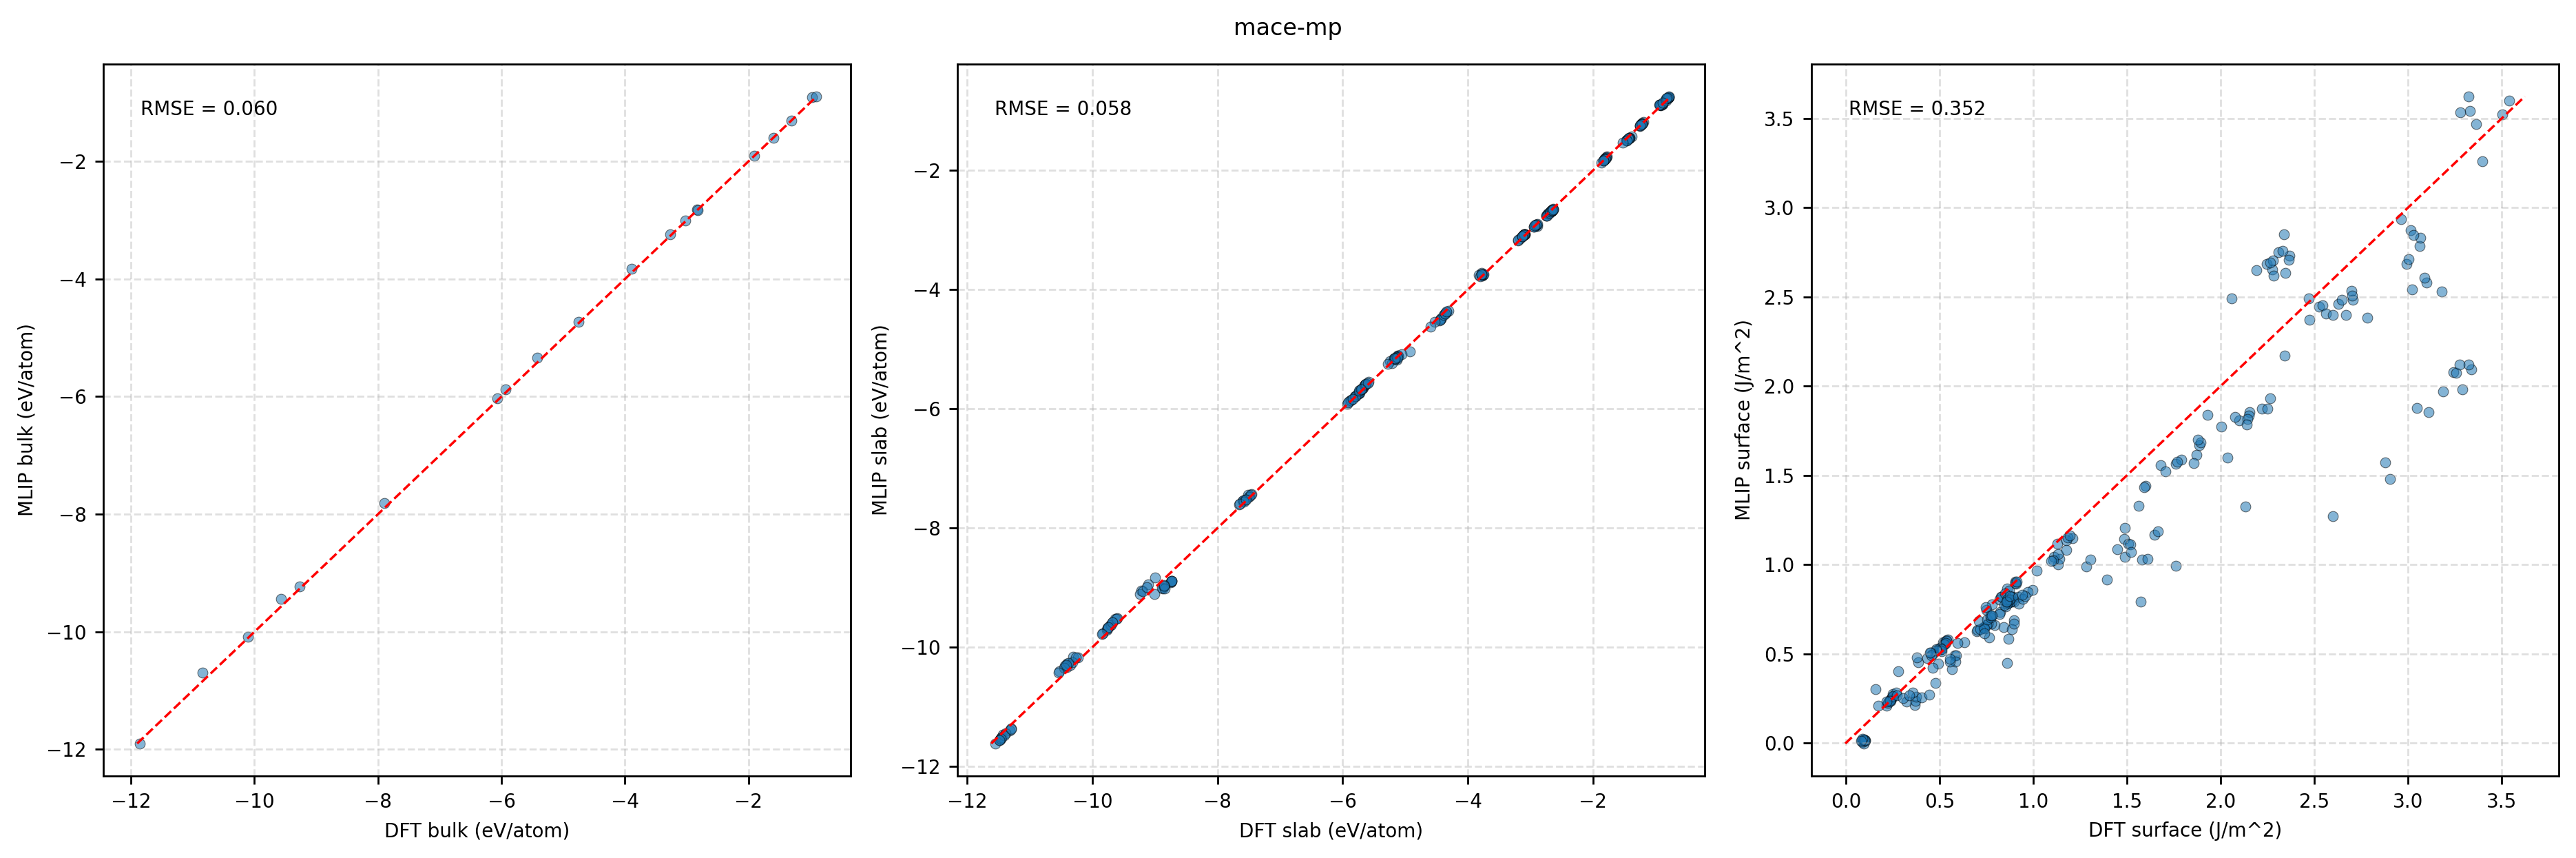

mace-mpa-0


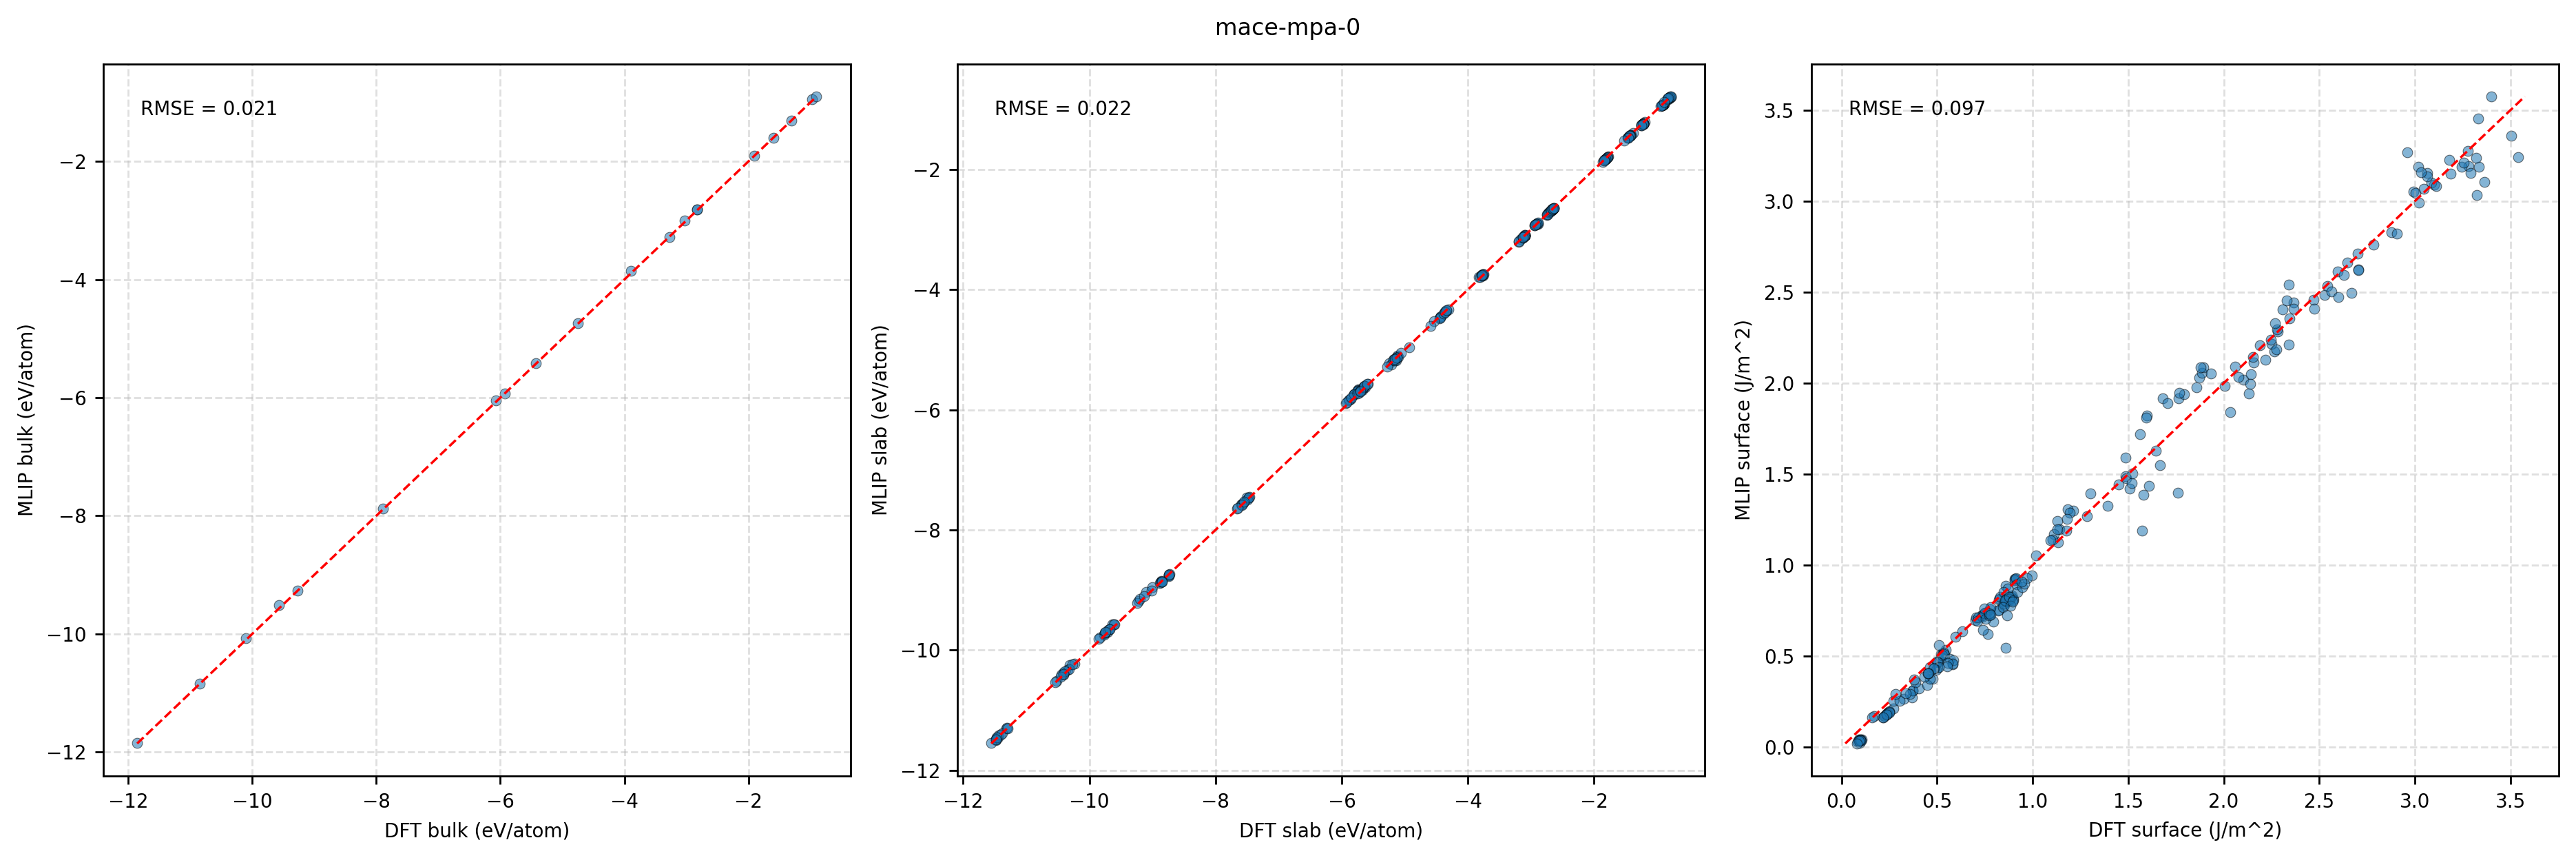

orb-v2-mptrj


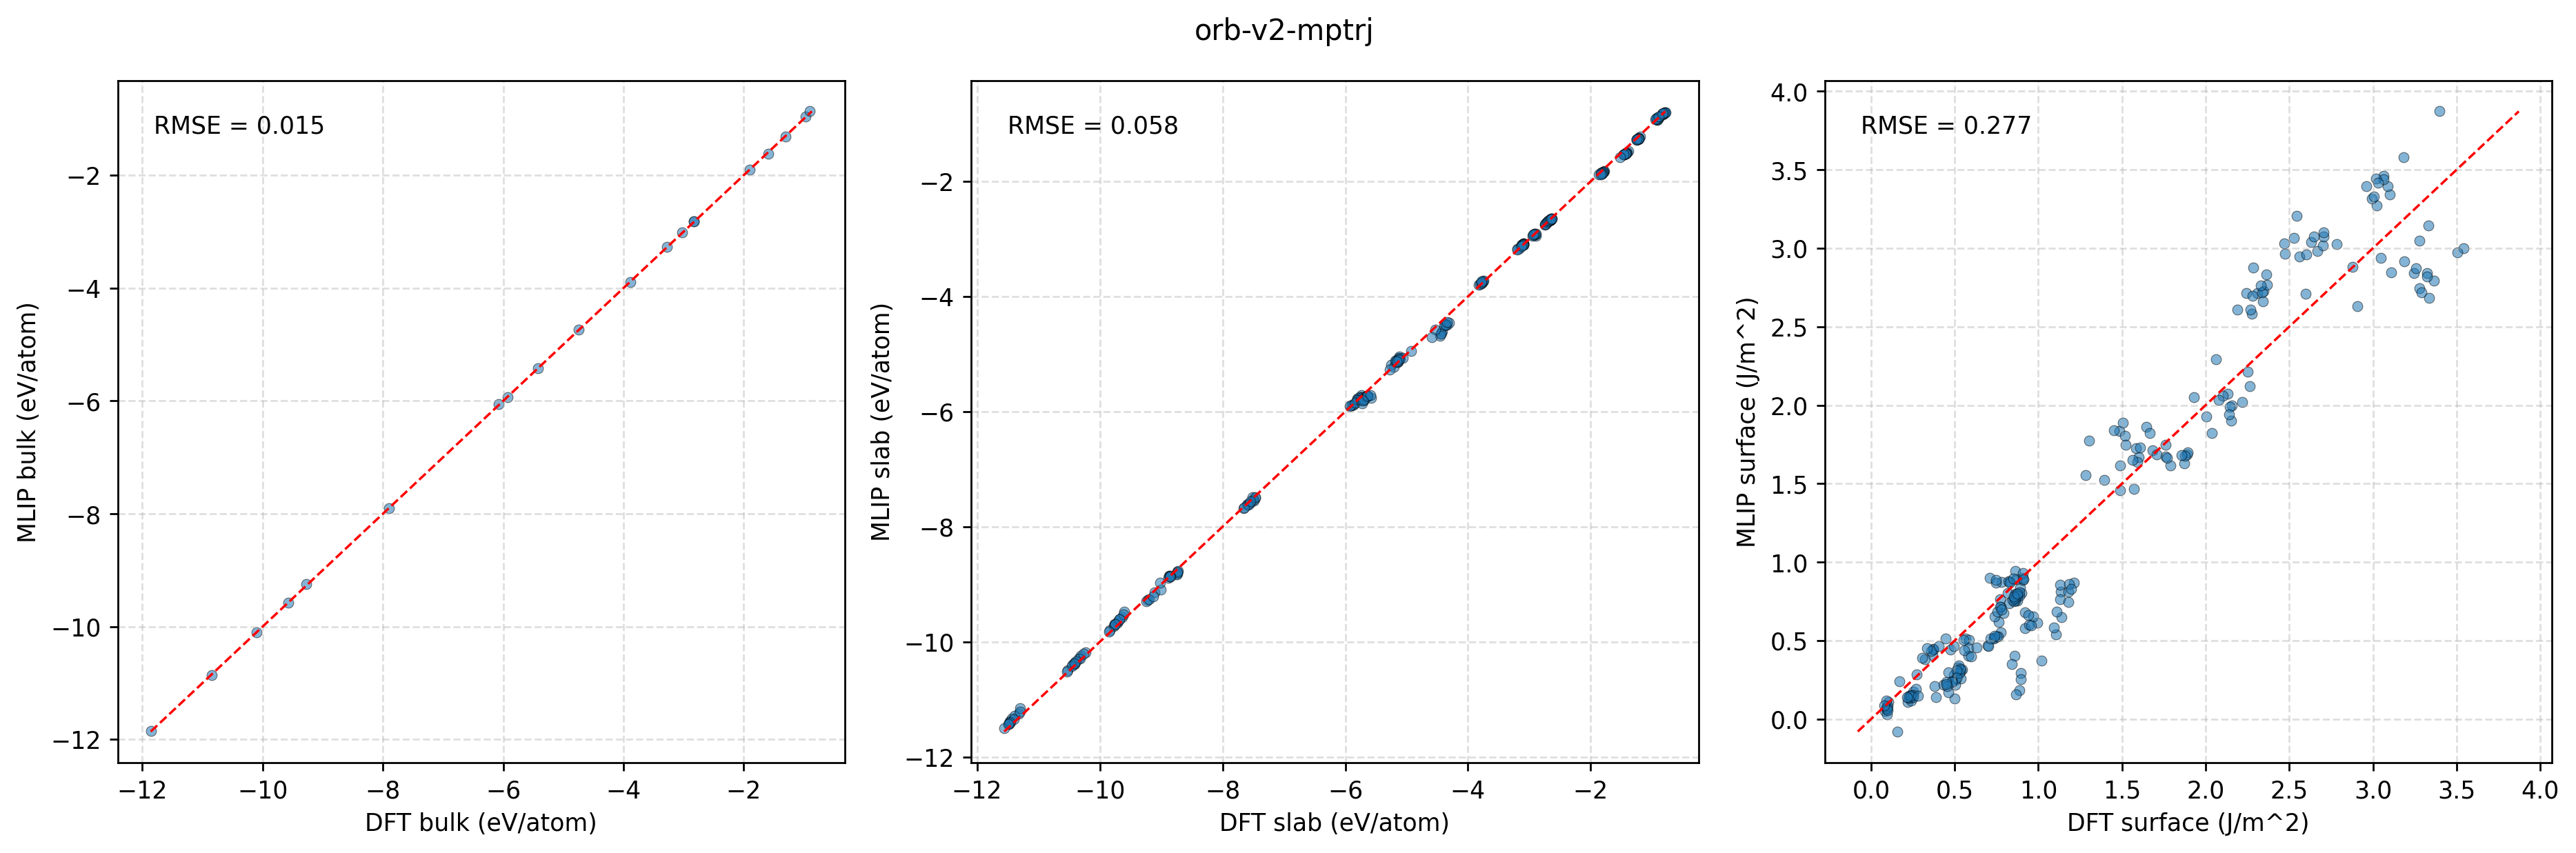

orb-v2


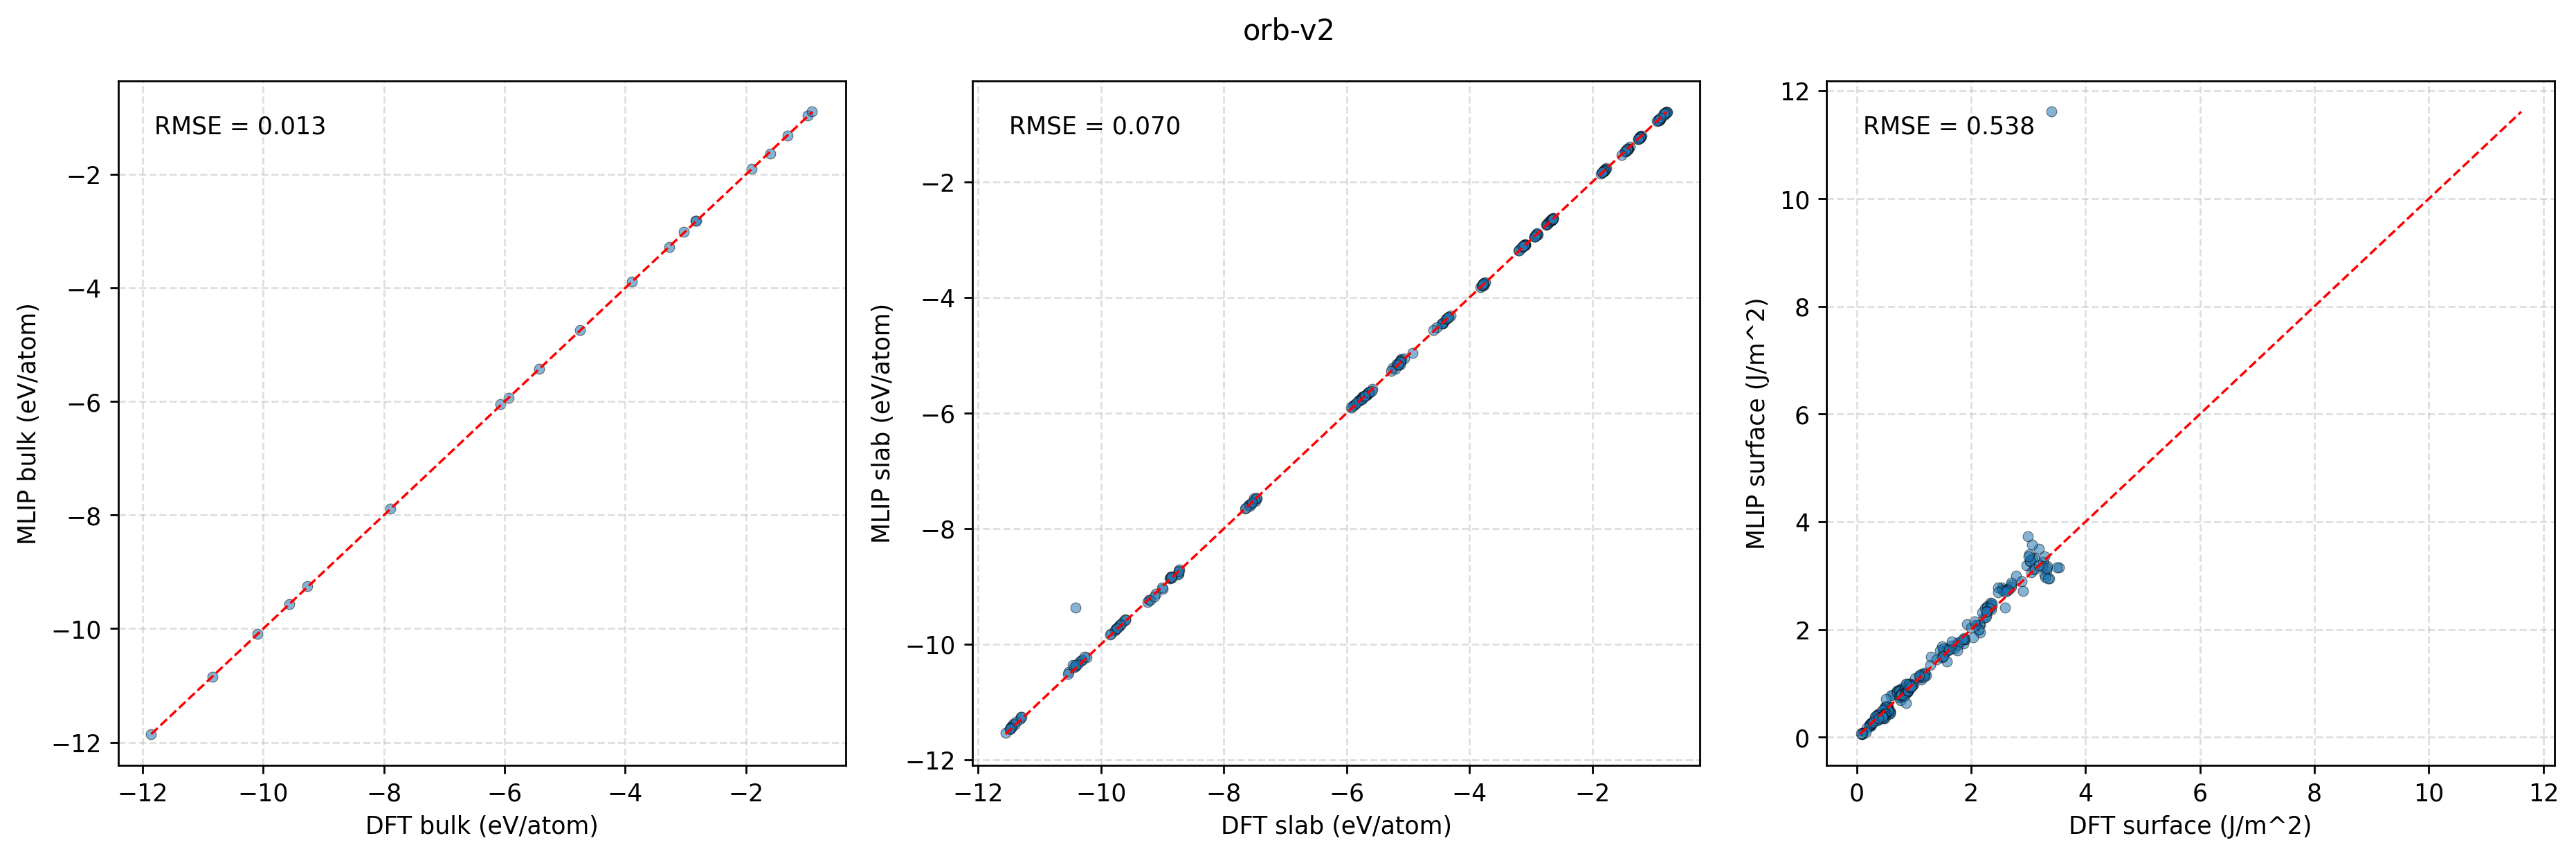

orb-v3


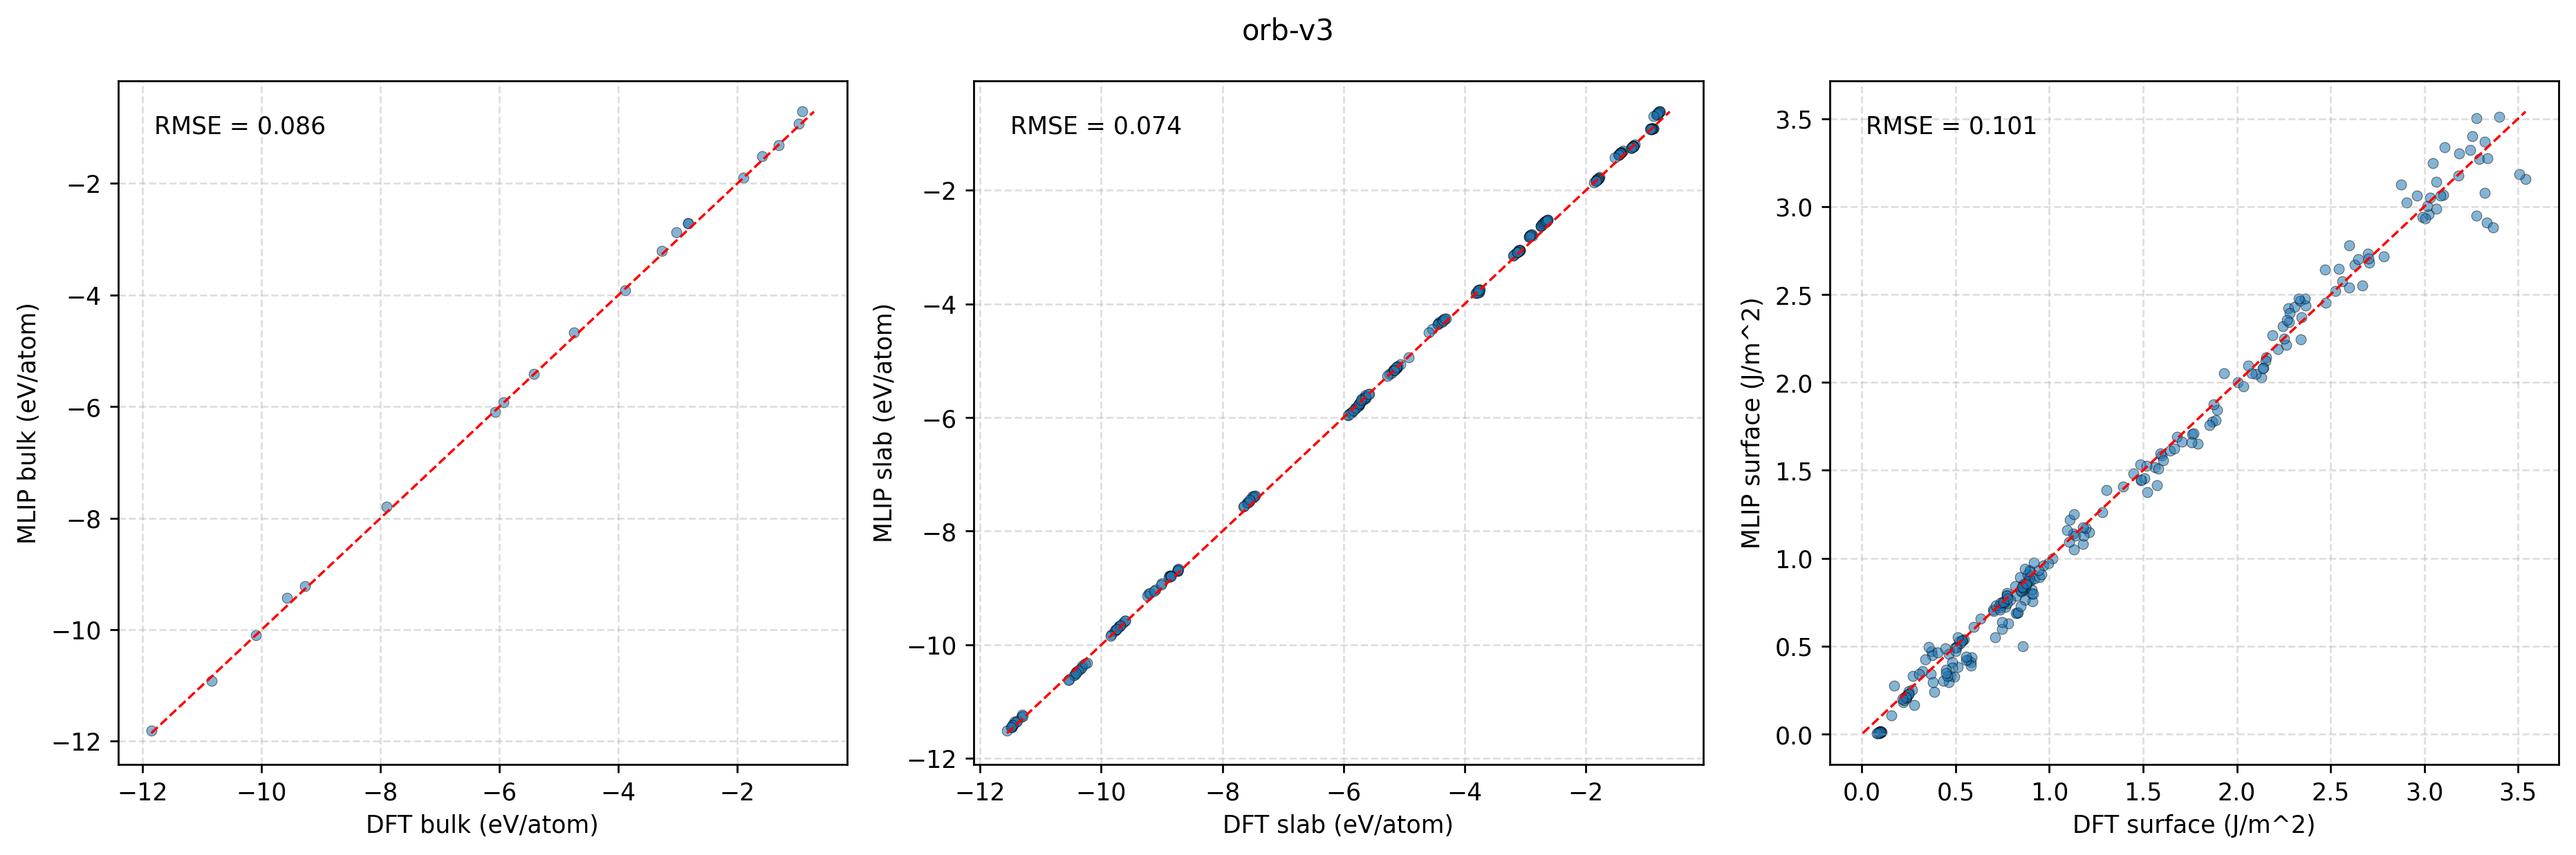

chgnet


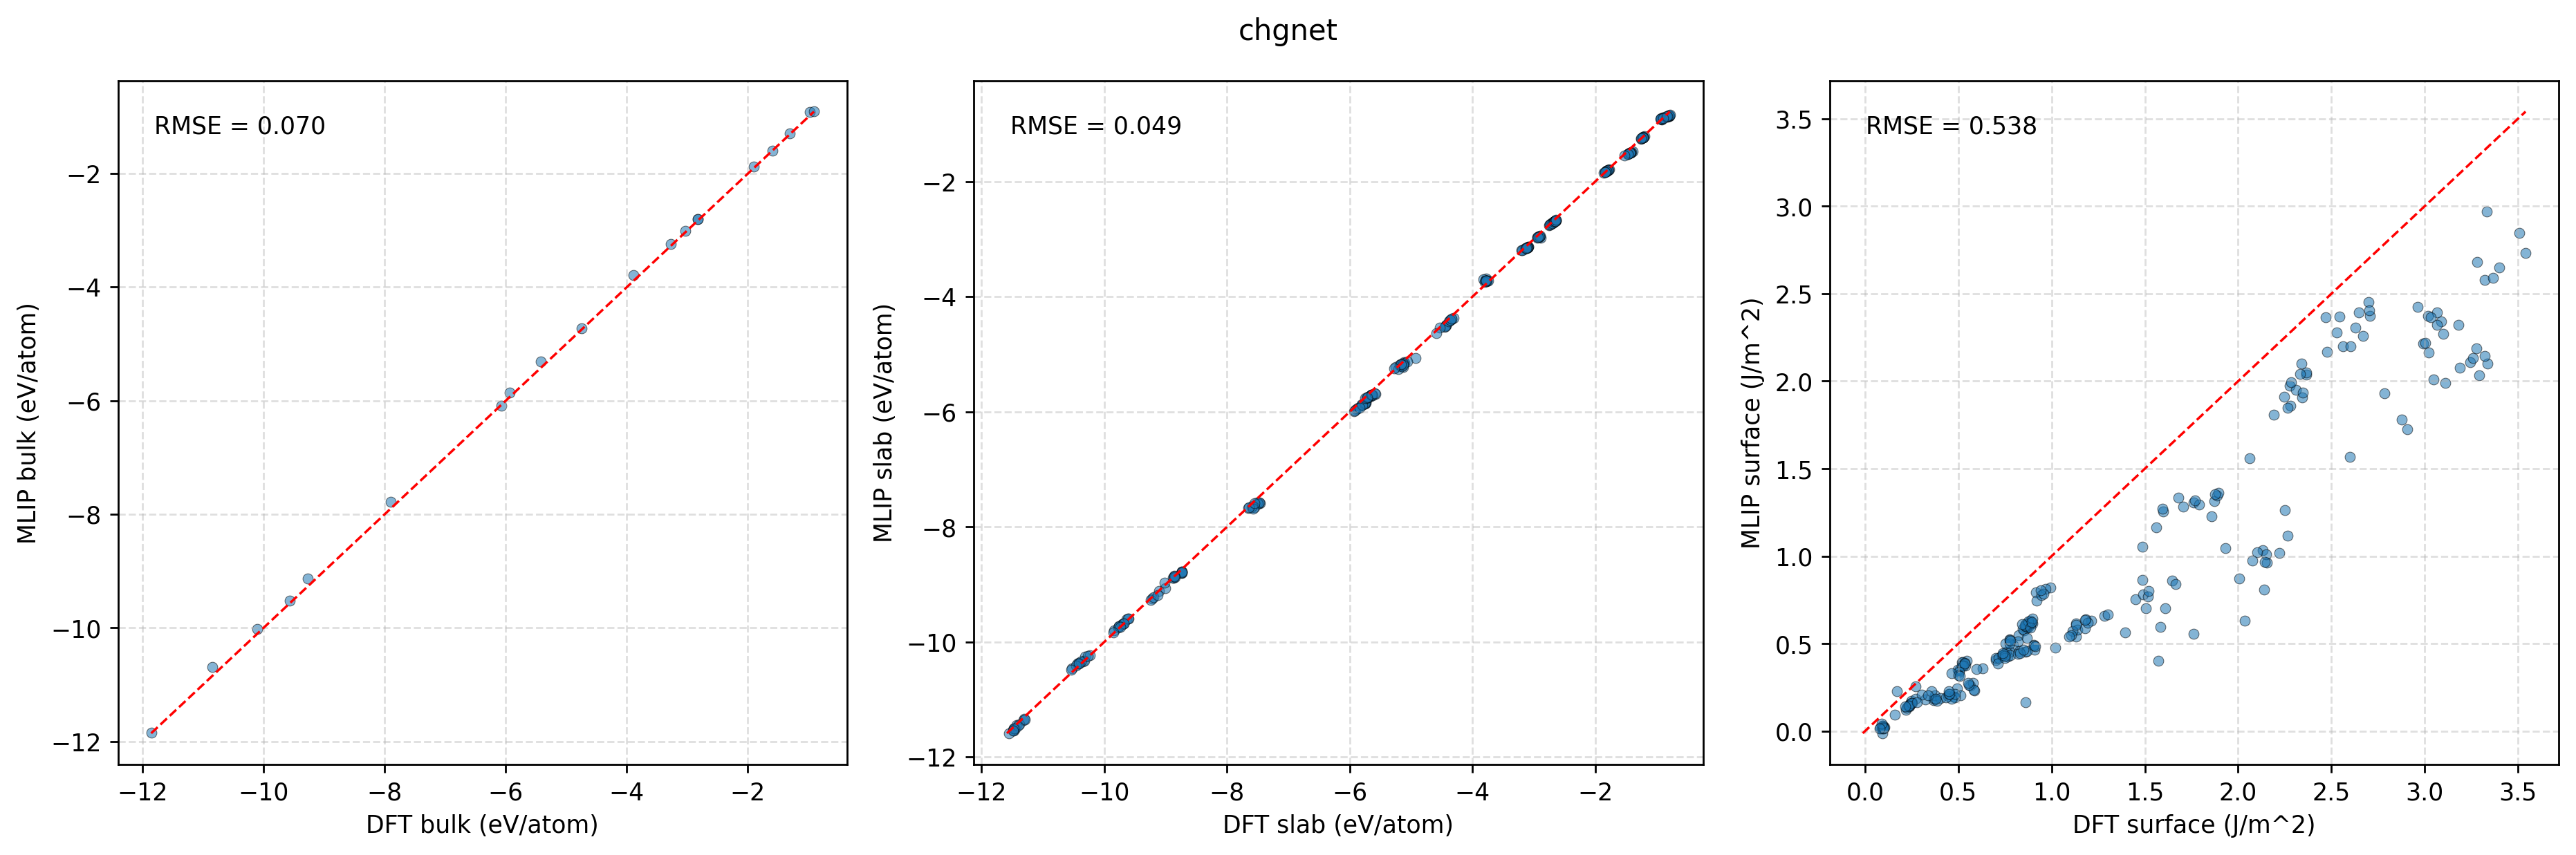

m3gnet


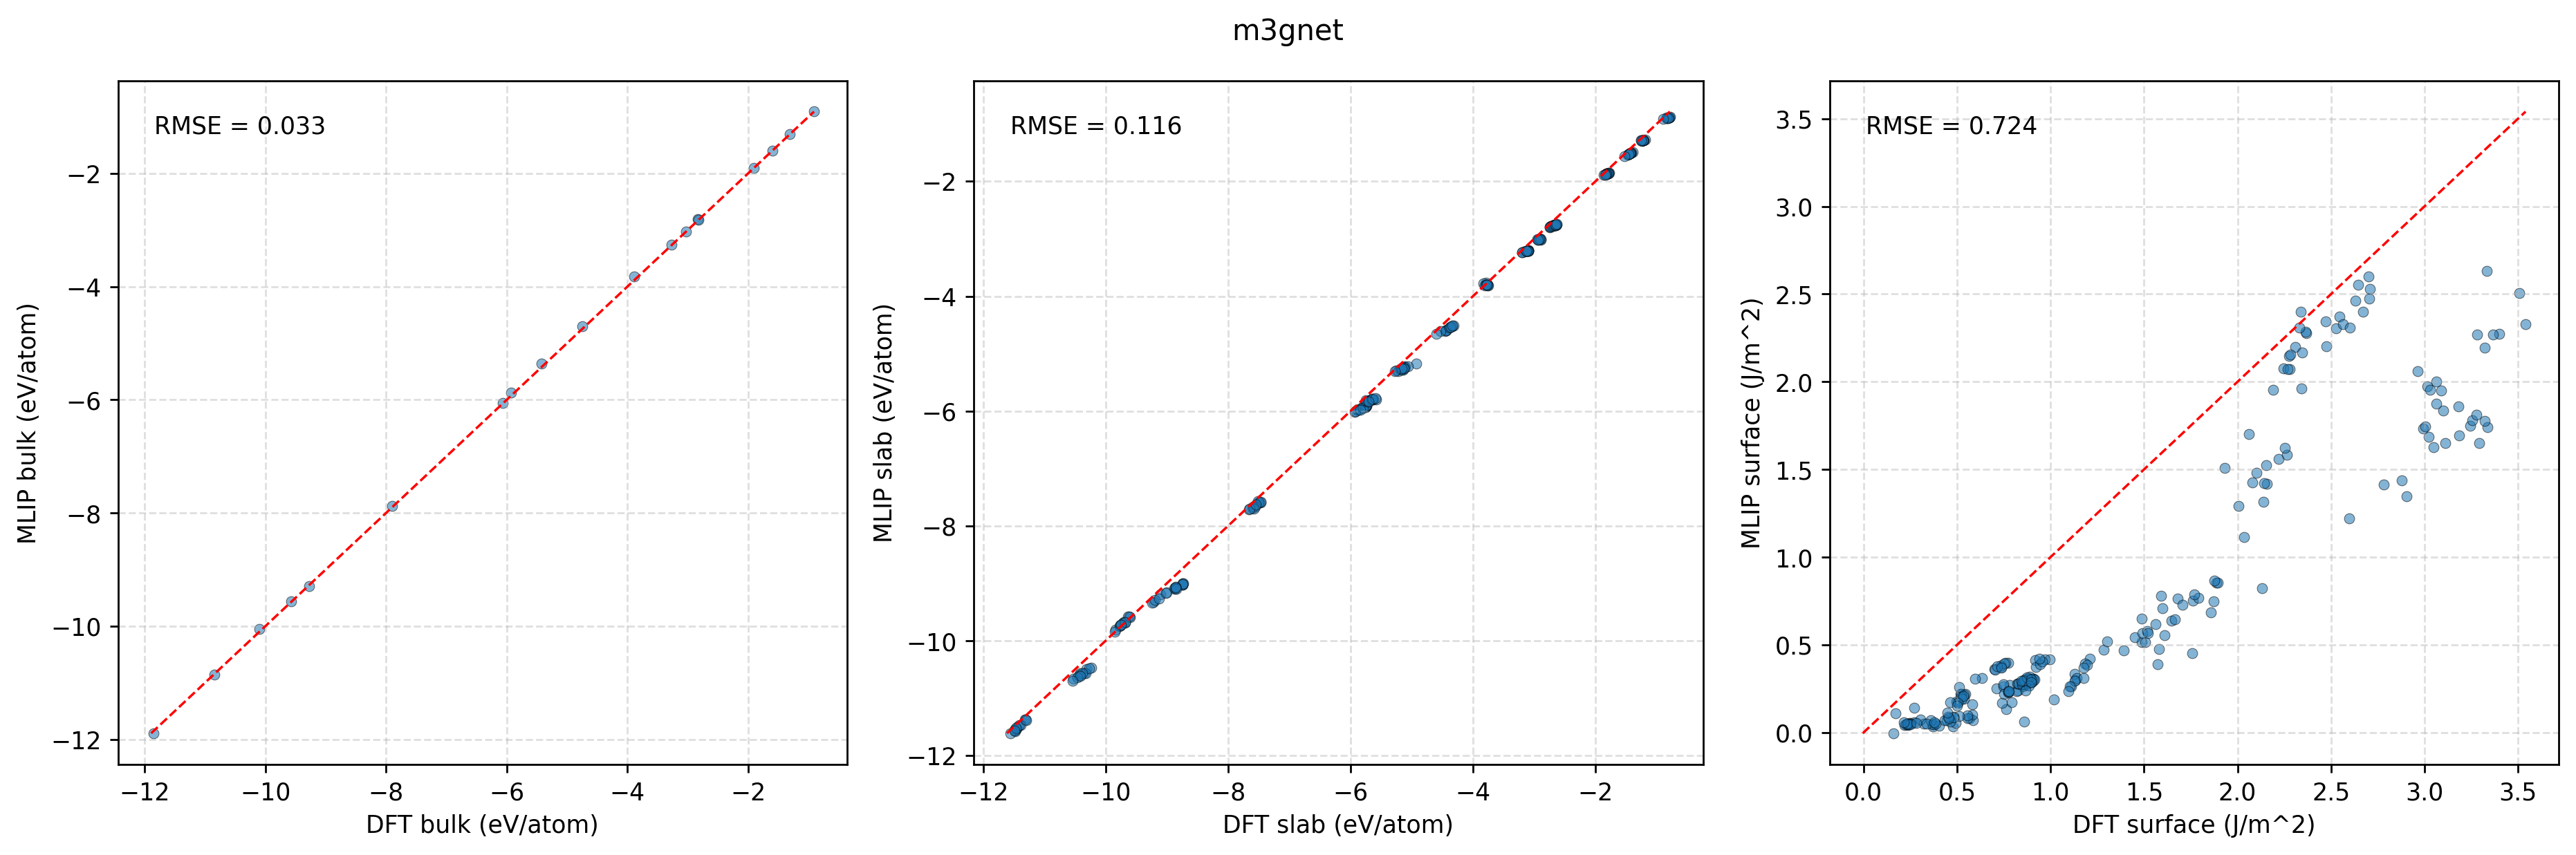

In [7]:
from IPython.display import Image, display

for model_name in MODELS:
    print(model_name)
    plot_path = f"data/surfaces/{model_name}/comparison_DFT_vs_{model_name}_surface.png"
    display(Image(filename=plot_path))

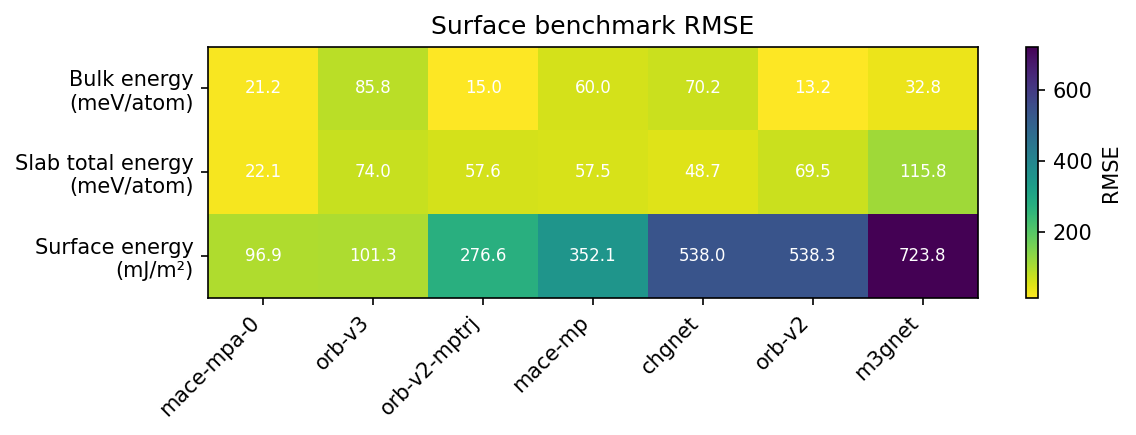

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df = pd.read_csv("data/rmse_results.csv")

df = df.drop_duplicates("calculator_name", keep="last")

metrics = {
    "Bulk energy\n(meV/atom)": "rmse_bulk_per_atom_meV",
    "Slab total energy\n(meV/atom)": "rmse_surface_total_per_atom_meV",
    "Surface energy\n(mJ/m²)": "rmse_surface_energy_mJ_m2",
}

heatmap = df.set_index("calculator_name")[[col for col in metrics.values() if col in df.columns]]

heatmap = heatmap.apply(pd.to_numeric, errors="coerce")

heatmap.columns = [label for label, col in metrics.items() if col in df.columns]

# ordenar antes de transpor
heatmap = heatmap.sort_values("Surface energy\n(mJ/m²)")

# transpor gráfico
heatmap = heatmap.T

fig, ax = plt.subplots(figsize=(8, 3), dpi=150)

im = ax.imshow(heatmap, cmap="viridis_r", aspect="auto")

ax.set_xticks(np.arange(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns, rotation=45, ha="right")

ax.set_yticks(np.arange(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        value = heatmap.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center", color="white", fontsize=8)

ax.set_title("Surface benchmark RMSE")

fig.colorbar(im, ax=ax, label="RMSE")

fig.tight_layout()
plt.show()

## Other IP-Orch features

The same package can also be used outside this notebook.

### CLI execution

```bash
ip-orch --run surfaces_benchmark.py --models mace-mp,orb-v3 --parallel 2
```

### Environment selection

Use `envs=[...]` when you want every configured model from one or more environments:

```python
orch.run(benchmark_surfaces, envs=["mace"], parallel=1)
```

Use `models=[...]` when you want explicit model aliases:

```python
orch.run(benchmark_surfaces, models=["mace-mp", "orb-v3"], parallel=2)
```

### Model registry

```python
orch.add_model("mace", "mace-mp")
orch.remove_model("mace", "mace-mp")
orch.supported_models("mace")
```

### Energy corrections

The repository also supports optional linear and element-reference energy corrections. These are useful when comparing models with different absolute energy references.

```python
orch.run(
    benchmark_surfaces,
    models=["mace-mp"],
    correction_elements=["Li", "O"],
    reference_energy_source="computed",
)
```

For models with bundled precomputed references:

```python
orch.run(
    benchmark_surfaces,
    models=["mace-mp"],
    reference_energy_source="precomputed",
)
```

### Local model files

Some model builders look for checkpoint files in a model directory. Pass that path with:

```python
orch.run(benchmark_surfaces, models=["nequip-mp-l"], models_path="/path/to/models")
```

The benchmark function does not need to know any of this. It only receives an ASE calculator.